# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [1]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

     - 0 bytes ? 0:00:00
     - 0 bytes ? 0:00:00


ERROR: Wheel 'en-core-web-sm' located at C:\Users\andhondi\AppData\Local\Temp\pip-unpack-t5nag98z\en_core_web_sm-3.7.1-py3-none-any.whl is invalid.


## Importing the necessary libraries

In [2]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# import train test split
from sklearn.model_selection import train_test_split

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [3]:
## Change the display properties of pandas to max
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [4]:
# Import the first file - True.csv
true_df = pd.read_csv('True.csv')

# Import the second file - Fake.csv
fake_df = pd.read_csv('Fake.csv')

## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [5]:
# Inspect the DataFrame with True News to understand the given data

true_df.describe()

,title,text,date
count,21417,21417,21417
unique,20826,21192,716
top,Factbox: Trump fills top jobs for his administration,"(Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a massive GBU-43 bomb, the largest non-nuclear bomb it has ever used in combat, in Afghanistan against a series of caves used by Islamic State militants, the Pentagon says. Trump says Pyongyang is a problem that “will be taken care of” amid speculation that North Korea is on the verge of a sixth nuclear test. Military force cannot resolve tension over North Korea, China warns, while an influential Chinese newspaper urges Pyongyang to halt its nuclear program in exchange for Beijing’s protection. The Trump administration is focusing its North Korea strategy on tougher economic sanctions, possibly including intercepting cargo ships and punishing Chinese banks doing business with Pyongyang, U.S. officials say. Trump says “things will work out fine” between the United States and Russia, a day after declaring U.S.-Russian relations may be at an all-time low. Trump signals he could be moving closer to the mainstream on monetary policy, saying he has not ruled out reappointment of Janet Yellen as Federal Reserve chair as he considers his choices for the U.S. central bank. [nL1N1HL14B] Trump signs a resolution that will allow U.S. states to restrict how federal funds for contraception and reproductive health are spent, a move cheered by anti-abortion campaigners. Democratic Senator Chris Van Hollen presses Deutsche Bank to release information about issues including Trump’s debt and any bank meetings with Trump administration officials, saying he has “great concern” about possible conflicts of interest. EXPORT-IMPORT BANK Trump’s office says he plans to revive the hobbled Export-Import Bank of the United States, a victory for American manufacturers such as Boeing Co and General Electric Co that have overseas customers that use the agency’s government-backed loans to purchase their products. Top Wall Street bankers say they are having positive discussions about financial regulation in Washington, and downplay the idea U.S. policymakers may force their institutions to split up. The United States is pushing for trade to be a key issue in top-level economic talks with Japan, a source says, an unwelcome development for Tokyo, which is seeking to fend off U.S. pressure to reduce the bilateral trade imbalance. Trump’s administration has focused on one group of illegal immigrants more than others: women with children, according to eight Department of Homeland Security officials interviewed by Reuters about agency planning.","December 20, 2017"
freq,14,8,182


In [6]:
# Inspect the DataFrame with Fake News to understand the given data

fake_df.describe()

,title,text,date
count,23502,23502,23481
unique,17914,17466,1692
top,MEDIA IGNORES Time That Bill Clinton FIRED His FBI Director On Day Before Vince Foster Was Found Dead,,"May 10, 2017"
freq,6,626,46


In [7]:
# Print the column details for True News DataFrame

true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB


In [8]:
# Print the column details for Fake News Dataframe

fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB


In [9]:
# Print the column names of both DataFrames

print("True News Dataframe Columns: " ,true_df.columns)
print("Fake News Dataframe Columns: " ,fake_df.columns)

True News Dataframe Columns:  Index(['title', 'text', 'date'], dtype='object')
Fake News Dataframe Columns:  Index(['title', 'text', 'date'], dtype='object')


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [10]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true

true_df['news_label'] = 1

# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake

fake_df['news_label'] = 0

### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [11]:
# Combine the true and fake news DataFrames into a single DataFrame

news_df = pd.concat([true_df,fake_df], ignore_index=True)

In [12]:
# Display the first 5 rows of the combined DataFrame to verify the result

news_df.head()

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [13]:
# Check Presence of Null Values

news_df.isnull().sum()

title         21
text          21
date          42
news_label     0
dtype: int64

In [14]:
# Handle Rows with Null Values

news_df.dropna(inplace=True)

In [15]:
news_df.shape

(44898, 4)

### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [16]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space

news_df['news_text'] = news_df['title'] + " " + news_df['text']

# Drop the irrelevant columns from the DataFrame as they are no longer needed

news_df.drop(['text'], inplace=True, axis=1)

# Display the first 5 rows of the updated DataFrame to check the result

news_df.head()

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                 date  news_label  \
0  December 31, 2017            1   
1  December 29, 2017            1   
2  December 31, 2017            1   
3  December 30, 2017            1   
4  December 29, 2017            1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [17]:
# Dropping dulicates from the data

news_df.drop_duplicates(inplace=True)
news_df.shape

(39110, 4)

## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [18]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed

df_clean = pd.DataFrame()

# Add 'news_label' column to the new dataframe for topic identification

df_clean['news_label'] = news_df['news_label']

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [19]:
# Write the function here to clean the text and remove all the unnecessary elements
import string

def Clean_text(col):
    # Convert to lower case
    lowered_text = col.str.lower()
    
    # Remove text in square brackets
    no_brackets = lowered_text.replace(r'\[.*?\]', '', regex=True)
    
    #Remove these special character words present in the datasource
    no_special_chars = no_brackets.replace(r'â€™*', '', regex=True)
    no_special_chars = no_special_chars.replace(r'“.”’', '', regex=True)
    
    # Remove punctuation
    all_punct = string.punctuation
    no_punct = no_special_chars.apply(lambda txt: txt.translate(str.maketrans('', '', all_punct)))
    
    # Remove words with numbers
    final_text = no_punct.replace(r'\b\w*\d\w*\b', '', regex=True)
    
    return final_text

#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [20]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame

df_clean['cleaned_news_text'] = Clean_text(news_df['news_text'])

In [21]:
df_clean.head()

news_label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [22]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags

def lemma_pos_tag(text):
    parsed_doc = nlp(text)
    # Extract lemma and POS tag for tokens that are not stopwords and have NN or NNS tag
    lemma_with_pos = [(tok.lemma_, tok.pos_) for tok in parsed_doc if not tok.is_stop and tok.tag_ in {'NN', 'NNS'}]
    return lemma_with_pos

#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [23]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame

tqdm.pandas()
df_clean.loc[:, 'lemma_pos'] = df_clean['cleaned_news_text'].progress_apply(lemma_pos_tag)

100%|████████████████████████████████████████████████████████████████████████████| 39110/39110 [24:44<00:00, 26.35it/s]


In [24]:
# Creating a new column by extracting only the lemma words (without POS tags)

df_clean.loc[:, 'lemma_text'] = df_clean['lemma_pos'].progress_apply(
    lambda tokens: " ".join(lemma for lemma, _ in tokens)
)

100%|█████████████████████████████████████████████████████████████████████████| 39110/39110 [00:00<00:00, 64639.68it/s]


### Save the Cleaned data as a csv file (Recommended)

In [25]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("clean_df.csv", index=False)
df_clean = pd.read_csv("clean_df.csv")

In [26]:
# Check the first few rows of the DataFrame
df_clean.head()

news_label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [27]:
# Check the dimensions of the DataFrame
df_clean.shape

(39110, 4)

In [28]:
# Check the number of non-null entries and data types of each column
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39110 entries, 0 to 39109
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   news_label         39110 non-null  int64 
 1   cleaned_news_text  39110 non-null  object
 2   lemma_pos          39110 non-null  object
 3   lemma_text         39101 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [29]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
df_clean_train, df_clean_test = train_test_split(
    df_clean, 
    train_size=0.7, 
    test_size=0.3, 
    random_state=42, 
    stratify=df_clean['news_label']
)

## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [30]:
# Add a new column to calculate the character length of cleaned news text
df_clean_train.loc[:, 'len_clean_text'] = df_clean_train['cleaned_news_text'].apply(lambda txt: len(txt))

# Add a new column to calculate the character length of lemmatized news text with POS tags removed
df_clean_train.loc[:, 'len_lemma_text'] = df_clean_train['lemma_text'].apply(
    lambda txt: len(txt) if isinstance(txt, str) else 0
)

In [31]:
df_clean_train.shape

(27377, 6)

##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

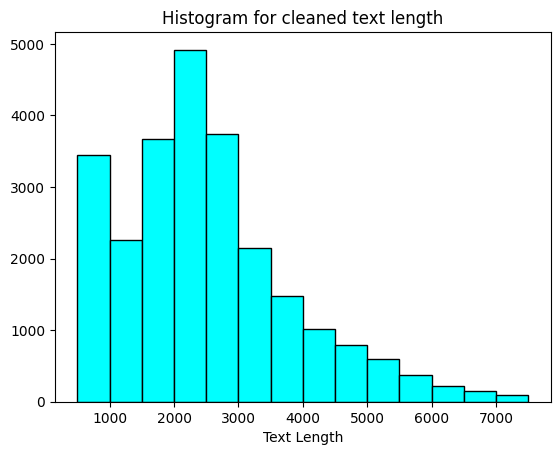

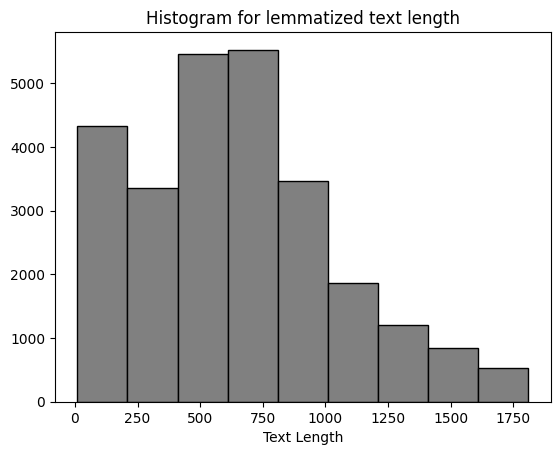

In [32]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text
bin_edges_clean = list(range(500, 8000, 500))
plt.hist(df_clean_train['len_clean_text'], bins=bin_edges_clean, color='cyan', edgecolor='black')
plt.xlabel('Text Length')
plt.title('Histogram for cleaned text length')
plt.show()

# Add histogram for lemmatized news text with POS tags removed
bin_edges_lemma = list(range(10, 2000, 200))
plt.hist(df_clean_train['len_lemma_text'], bins=bin_edges_lemma, color='grey', edgecolor='black')
plt.xlabel('Text Length')
plt.title('Histogram for lemmatized text length')
plt.show()

### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

In [33]:
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

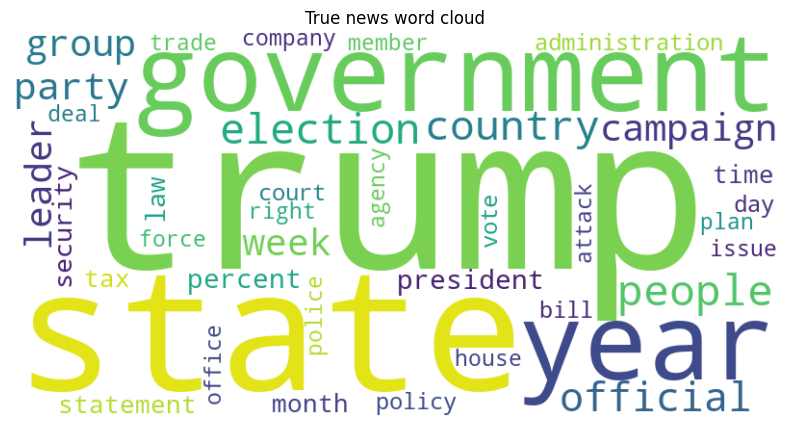

In [34]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
df_clean_train_true = df_clean_train[df_clean_train['news_label'] == 1]

# creating text from the cleaned text column
combined_text = " ".join(str(item) for item in df_clean_train_true['lemma_text'])

# Count the frequency of each word
freq_counts = Counter(combined_text.split())

# Get the 40 most common words
top_words_40 = dict(freq_counts.most_common(40))

# Generate word cloud for True News
true_news_wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words_40)

plt.figure(figsize=(10, 5))
plt.imshow(true_news_wc, interpolation='bilinear')
plt.axis('off')
plt.title("True news word cloud")
plt.show()

##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

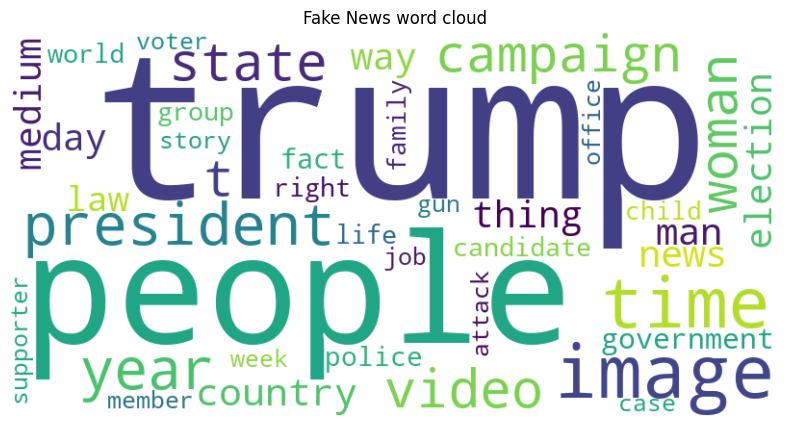

In [35]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
df_clean_train_fake = df_clean_train[df_clean_train['news_label'] == 0]

# creating text from the cleaned text column
fake_text_combined = " ".join(str(item) for item in df_clean_train_fake['lemma_text'])

# Count the frequency of each word
fake_word_counts = Counter(fake_text_combined.split())

# Get the 40 most common words
fake_top_40 = dict(fake_word_counts.most_common(40))

# Generate word cloud for fake News
fake_news_wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(fake_top_40)

plt.figure(figsize=(10, 5))
plt.imshow(fake_news_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Fake News word cloud")
plt.show()

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [36]:
# Write a function to get the specified top n-grams
def generate_ngrams(text, n, top_n):
    # Splitting the input text and creating a lsit
    words_filtered = [w for w in text.split() if isinstance(w, str) and w.isalpha() and len(w) > 2]
    
    # creating tuple based on n size
    ngram_tuples = [tuple(words_filtered[i:i+n]) for i in range(len(words_filtered) - n + 1)]
    
    # Count frequencies of n-grams
    ngram_counts = Counter(ngram_tuples)
    
    # Get the top n most common n-grams
    return ngram_counts.most_common(top_n)


# function to plot the graph
# function to plot the graph with customization options
def plot_bar_graph(data, color='skyblue', title='N-gram Frequency', xlabel='Frequency', ylabel='N-grams'):
    # Unpack n-grams and their counts
    ngram_seq, freq = zip(*data)
    
    # Convert tuples of tokens into joined string labels
    ngram_labels = [' '.join(seq) if isinstance(seq, (list, tuple)) else seq for seq in ngram_seq]
    
    # Plot horizontal bar chart
    plt.figure(figsize=(8, 5))
    plt.barh(ngram_labels, freq, color=color)
    
    # Add labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    
    # Add grid for better readability
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.gca().invert_yaxis()
    
    plt.tight_layout()
    plt.show()

##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [37]:
# Handle NaN values in the text data
df_clean_train_true.dropna(axis=0, inplace=True)
df_clean_train_true.isnull().sum()

news_label           0
cleaned_news_text    0
lemma_pos            0
lemma_text           0
len_clean_text       0
len_lemma_text       0
dtype: int64

In [38]:
df_clean_train_fake.dropna(inplace=True)
df_clean_train_fake.isna().sum()

news_label           0
cleaned_news_text    0
lemma_pos            0
lemma_text           0
len_clean_text       0
len_lemma_text       0
dtype: int64

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

[(('trump',), 24889), (('state',), 14145), (('government',), 13511), (('year',), 13154), (('people',), 10518), (('election',), 10103), (('country',), 9708), (('official',), 9075), (('party',), 8287), (('campaign',), 7736)]


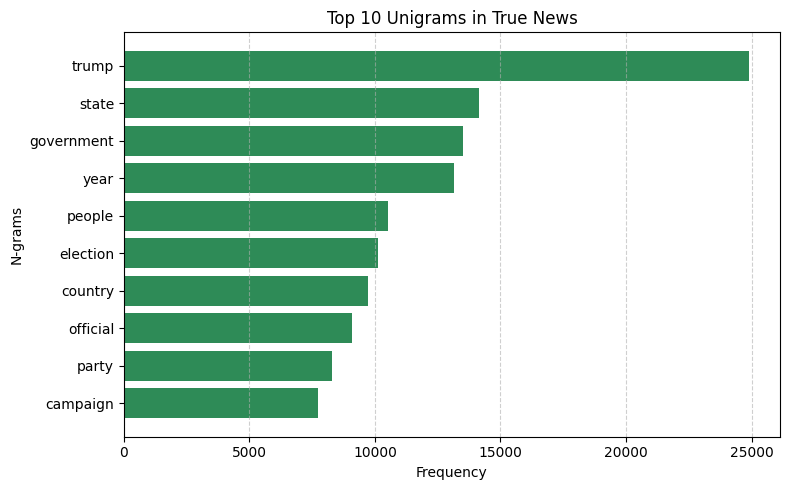

In [39]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
top10_true_unigrams = generate_ngrams(" ".join(df_clean_train_true['lemma_text']), n=1, top_n=10)
print(top10_true_unigrams)

# Use improved function with custom color and title
plot_bar_graph(top10_true_unigrams, color='seagreen', title='Top 10 Unigrams in True News')

##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



[(('trump', 'campaign'), 1218), (('news', 'conference'), 955), (('percent', 'percent'), 859), (('tax', 'reform'), 767), (('climate', 'change'), 740), (('request', 'comment'), 727), (('security', 'force'), 693), (('trump', 'administration'), 663), (('house', 'representative'), 652), (('intelligence', 'agency'), 636)]


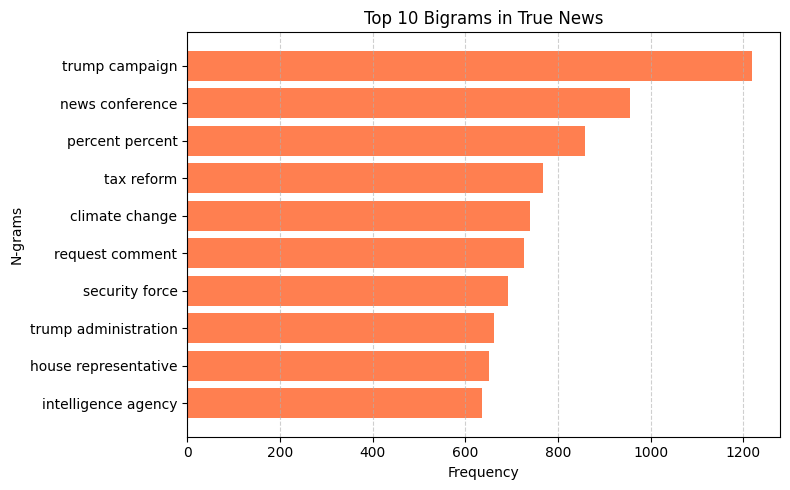

In [40]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
top_10_bigram_true = generate_ngrams(" ".join(df_clean_train_true['lemma_text']), n=2, top_n=10)
print(top_10_bigram_true)

# Use improved bar plot function with custom title and color
plot_bar_graph(top_10_bigram_true, color='coral', title='Top 10 Bigrams in True News', xlabel='Frequency')

##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



[(('official', 'condition', 'anonymity'), 215), (('trump', 'transition', 'team'), 185), (('tax', 'rate', 'percent'), 169), (('article', 'staff', 'involvement'), 133), (('staff', 'involvement', 'creation'), 133), (('involvement', 'creation', 'production'), 133), (('percent', 'percent', 'percent'), 130), (('rate', 'percent', 'percent'), 120), (('use', 'email', 'server'), 117), (('state', 'department', 'official'), 112)]


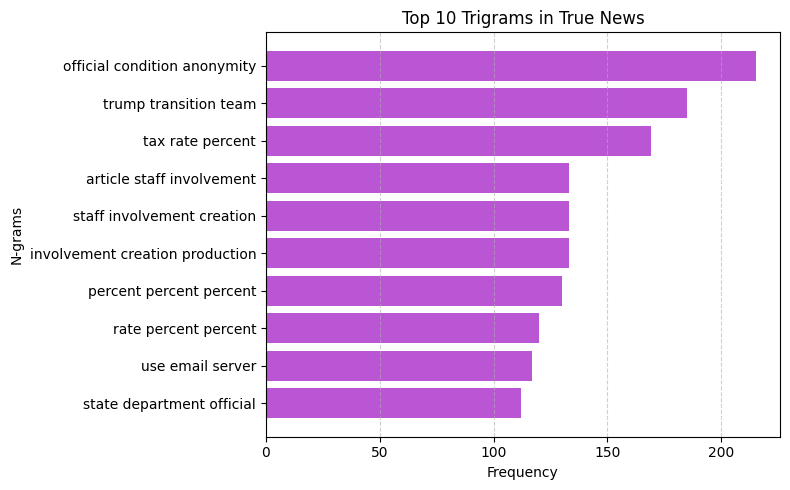

In [41]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
top_10_trigram_true = generate_ngrams(" ".join(df_clean_train_true['lemma_text']), n=3, top_n=10)
print(top_10_trigram_true)

# Use the improved plot function with a custom title and color for better visualization
plot_bar_graph(
    top_10_trigram_true,
    color='mediumorchid',   # custom color to differentiate trigrams
    title='Top 10 Trigrams in True News',
    xlabel='Frequency'
)

### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

[(('trump',), 31192), (('people',), 14604), (('image',), 9452), (('time',), 8584), (('president',), 7911), (('year',), 7641), (('woman',), 6707), (('state',), 6638), (('video',), 6624), (('campaign',), 6109)]


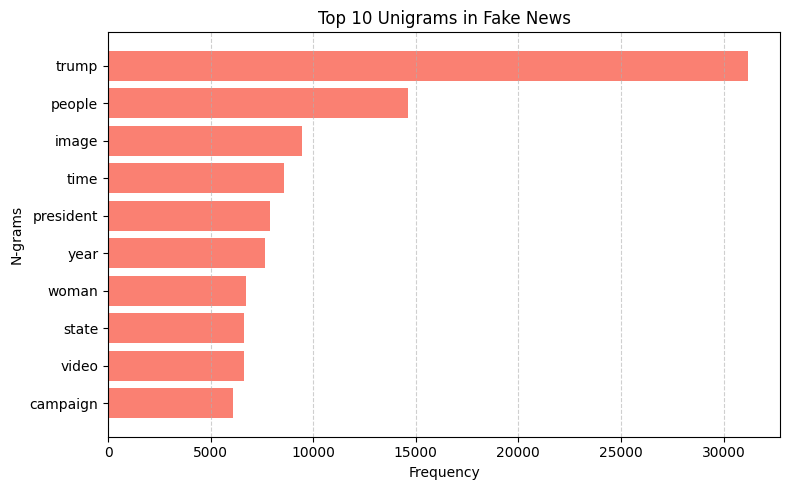

In [42]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
top_10_unigram_false = generate_ngrams(" ".join(df_clean_train_fake['lemma_text']), n=1, top_n=10)
print(top_10_unigram_false)

# Plot with improved function and custom color for visual distinction
plot_bar_graph(
    top_10_unigram_false,
    color='salmon',                 # Different color for fake news
    title='Top 10 Unigrams in Fake News',
    xlabel='Frequency'
)

##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



[(('image', 'image'), 1279), (('trump', 'supporter'), 1192), (('trump', 'campaign'), 1023), (('screen', 'capture'), 940), (('police', 'officer'), 829), (('trump', 'realdonaldtrump'), 790), (('donald', 'trump'), 778), (('image', 'video'), 750), (('law', 'enforcement'), 719), (('century', 'wire'), 683)]


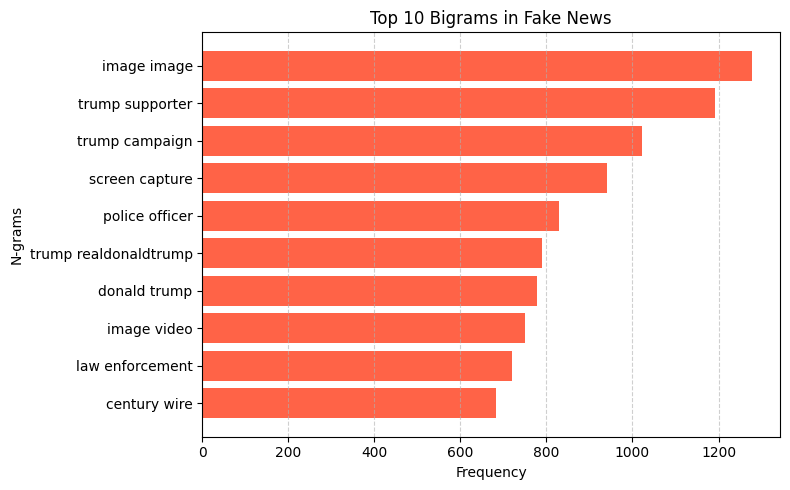

In [43]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
top_10_bigram_false = generate_ngrams(" ".join(df_clean_train_fake['lemma_text']), n=2, top_n=10)
print(top_10_bigram_false)

# Plot with improved function and custom color for better differentiation
plot_bar_graph(
    top_10_bigram_false,
    color='tomato',                     # Use a different shade to distinguish from unigrams
    title='Top 10 Bigrams in Fake News',
    xlabel='Frequency'
)

##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



[(('video', 'screen', 'capture'), 529), (('image', 'video', 'screen'), 502), (('image', 'getty', 'image'), 407), (('news', 'century', 'wire'), 330), (('image', 'screen', 'capture'), 315), (('image', 'chip', 'image'), 184), (('image', 'video', 'screenshot'), 164), (('image', 'image', 'trump'), 163), (('law', 'enforcement', 'officer'), 110), (('screen', 'capture', 'trump'), 95)]


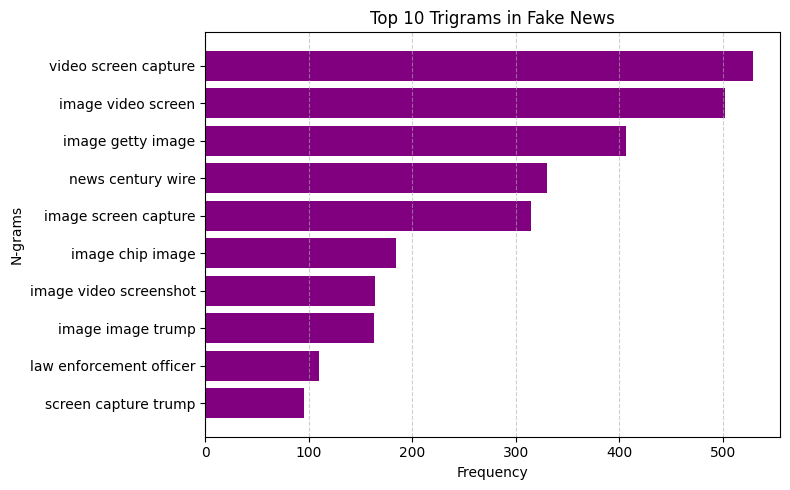

In [44]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
top_10_trigram_false = generate_ngrams(" ".join(df_clean_train_fake['lemma_text']), n=3, top_n=10)
print(top_10_trigram_false)

# Use improved bar plot with custom color and title
plot_bar_graph(
    top_10_trigram_false,
    color='purple',                      # distinct color for trigrams
    title='Top 10 Trigrams in Fake News',
    xlabel='Frequency'
)

## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [45]:
# Add a new column to calculate the character length of cleaned news text

# Add a new column to calculate the character length of lemmatized news text with POS tags removed


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

In [46]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed


### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

In [47]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text

# Generate word cloud for True News


##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

In [48]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Generate word cloud for Fake News


### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [49]:
## Write a function to get the specified top n-grams


##### 5.3.2 Handle the NaN values

In [50]:
## First handle NaN values in the text data


### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

In [51]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph


##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

In [52]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

In [53]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph


### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

In [54]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

In [55]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

In [56]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph


## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [60]:
import gensim.downloader as api
import gensim

In [63]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
Word2vec_model = api.load("word2vec-google-news-300")

In [64]:
Word2vec_model.vectors.shape

(3000000, 300)

### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [65]:
# Drop rows with NaN values from train and test sets
df_clean_train.dropna(inplace=True)
df_clean_test.dropna(inplace=True)

# Verify if any NaN values remain in the training set
df_clean_train.isna().sum()

news_label           0
cleaned_news_text    0
lemma_pos            0
lemma_text           0
len_clean_text       0
len_lemma_text       0
dtype: int64

In [66]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data

# For train data
df_clean_train_vec = np.array([
    np.mean(
        [Word2vec_model[word] if word in Word2vec_model else np.zeros(Word2vec_model.vector_size) 
         for word in str(sentence).split()], 
        axis=0
    ) if str(sentence).strip() else np.zeros(Word2vec_model.vector_size)
    for sentence in df_clean_train['lemma_text']
])

# For test data
df_clean_test_vec = np.array([
    np.mean(
        [Word2vec_model[word] if word in Word2vec_model else np.zeros(Word2vec_model.vector_size) 
         for word in str(sentence).split()], 
        axis=0
    ) if str(sentence).strip() else np.zeros(Word2vec_model.vector_size)
    for sentence in df_clean_test['lemma_text']
])

## Extract the target variable for the training data and validation data

y_train = df_clean_train['news_label'].values
y_test = df_clean_test['news_label'].values

## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [68]:
## Initialise Logistic Regression model

lr = LogisticRegression(random_state=42, max_iter=500)

## Train Logistic Regression model on training data

lr_model = lr.fit(df_clean_train_vec, y_train)

## Predict on validation data

# Predictions on training data
y_train_pred_lr = lr_model.predict(df_clean_train_vec)

# Predictions on test/validation data
y_test_pred_lr = lr_model.predict(df_clean_test_vec)

##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [69]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels

# Training metrics
acc_lr_train = accuracy_score(y_train, y_train_pred_lr)
pr_lr_train  = precision_score(y_train, y_train_pred_lr)
rc_lr_train  = recall_score(y_train, y_train_pred_lr)
f1_lr_train  = f1_score(y_train, y_train_pred_lr)

print("\n--- Training Metrics ---")
print(f"Training Accuracy  : {acc_lr_train:.4f}")
print(f"Training Precision : {pr_lr_train:.4f}")
print(f"Training Recall    : {rc_lr_train:.4f}")
print(f"Training F1-score  : {f1_lr_train:.4f}")

# Validation/Test metrics
acc_lr_test = accuracy_score(y_test, y_test_pred_lr)
pr_lr_test  = precision_score(y_test, y_test_pred_lr)
rc_lr_test  = recall_score(y_test, y_test_pred_lr)
f1_lr_test  = f1_score(y_test, y_test_pred_lr)

print("\n--- Validation Metrics ---")
print(f"Validation Accuracy  : {acc_lr_test:.4f}")
print(f"Validation Precision : {pr_lr_test:.4f}")
print(f"Validation Recall    : {rc_lr_test:.4f}")
print(f"Validation F1-score  : {f1_lr_test:.4f}")


--- Training Metrics ---
Training Accuracy  : 0.9139
Training Precision : 0.9145
Training Recall    : 0.9278
Training F1-score  : 0.9211

--- Validation Metrics ---
Validation Accuracy  : 0.9133
Validation Precision : 0.9131
Validation Recall    : 0.9285
Validation F1-score  : 0.9207


In [70]:
# Classification Report

print("Classification Report:\n", classification_report(y_test, y_test_pred_lr))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90      5370
           1       0.91      0.93      0.92      6360

    accuracy                           0.91     11730
   macro avg       0.91      0.91      0.91     11730
weighted avg       0.91      0.91      0.91     11730



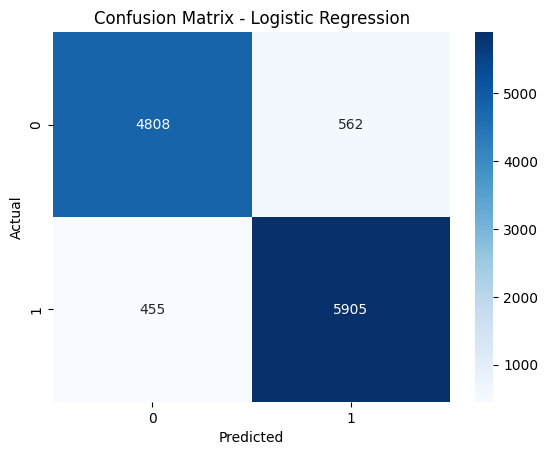

In [71]:
# Confusion Metrix for better visuals

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [72]:
## Initialise Decision Tree model

decision_tree_model = DecisionTreeClassifier(random_state=42)

## Train Decision Tree model on training data

decision_tree_model.fit(df_clean_train_vec, y_train)

## Predict on validation data

y_pred_decision_tree = decision_tree_model.predict(df_clean_test_vec)

In [73]:
# Define a grid of hyperparameters to explore for optimal performance
param_grid_dt = {
    'max_depth': range(1, 10, 2),
    'max_features': range(1, 10, 2),
    'min_samples_leaf': range(1, 150, 50)
}

In [74]:
# Initialize GridSearchCV for hyperparameter optimization with 3-fold cross-validation
grid_search_dt = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=param_grid_dt,
    cv=3,
    verbose=1,
    return_train_score=True
)

In [75]:
# Execute the grid search on the training data
grid_search_dt.fit(df_clean_train_vec, y_train)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': range(1, 10, 2), 'max_features': range(1, 10, 2), 'min_samples_leaf': range(1, 150, 50)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [76]:
# Display the best hyperparameter combination found during the search
print("Optimal hyperparameters for Decision Tree:", grid_search_dt.best_params_)

Optimal hyperparameters for Decision Tree: {'max_depth': 9, 'max_features': 9, 'min_samples_leaf': 51}


In [77]:
# Instantiate a Decision Tree Classifier with the tuned parameters obtained
best_dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=grid_search_dt.best_params_['max_depth'],
    max_features=grid_search_dt.best_params_['max_features'],
    min_samples_leaf=grid_search_dt.best_params_['min_samples_leaf']
)

In [78]:
# Fit the tuned Decision Tree model on the training data
best_dt_model.fit(df_clean_train_vec, y_train)

# Predict on the training data using tuned Decision Tree
y_train_pred_dt = best_dt_model.predict(df_clean_train_vec)

# Predict on the valdation data using tuned Decision Tree
y_test_pred_dt = best_dt_model.predict(df_clean_test_vec)

##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [79]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels

# Training metrics
acc_dt_train = accuracy_score(y_train, y_train_pred_dt)
pr_dt_train  = precision_score(y_train, y_train_pred_dt)
rc_dt_train  = recall_score(y_train, y_train_pred_dt)
f1_dt_train  = f1_score(y_train, y_train_pred_dt)

print("\n--- Training Metrics ---")
print(f"Training Accuracy  : {acc_dt_train:.4f}")
print(f"Training Precision : {pr_dt_train:.4f}")
print(f"Training Recall    : {rc_dt_train:.4f}")
print(f"Training F1-score  : {f1_dt_train:.4f}")

# Validation/Test metrics
acc_dt_test = accuracy_score(y_test, y_test_pred_dt)
pr_dt_test  = precision_score(y_test, y_test_pred_dt)
rc_dt_test  = recall_score(y_test, y_test_pred_dt)
f1_dt_test  = f1_score(y_test, y_test_pred_dt)

print("\n--- Validation Metrics ---")
print(f"Validation Accuracy  : {acc_dt_test:.4f}")
print(f"Validation Precision : {pr_dt_test:.4f}")
print(f"Validation Recall    : {rc_dt_test:.4f}")
print(f"Validation F1-score  : {f1_dt_test:.4f}")


--- Training Metrics ---
Training Accuracy  : 0.8246
Training Precision : 0.8255
Training Recall    : 0.8579
Training F1-score  : 0.8414

--- Validation Metrics ---
Validation Accuracy  : 0.7975
Validation Precision : 0.8012
Validation Recall    : 0.8333
Validation F1-score  : 0.8170


In [80]:
# Classification Report

print("Classification Report:\n", classification_report(y_test, y_test_pred_dt))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77      5370
           1       0.80      0.83      0.82      6360

    accuracy                           0.80     11730
   macro avg       0.80      0.79      0.80     11730
weighted avg       0.80      0.80      0.80     11730



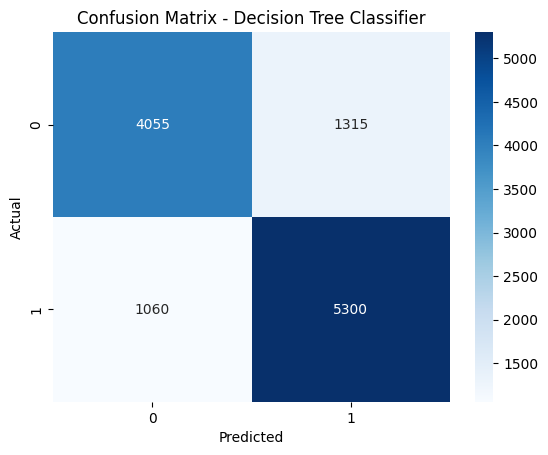

In [81]:
# Confusion Metrix for better visuals

cm = confusion_matrix(y_test, y_test_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [82]:
## Initialise Random Forest model

rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)

## Train Random Forest model on training data

rf_classifier.fit(df_clean_train_vec, y_train)

## Predict on validation data

y_pred_rf = rf_classifier.predict(df_clean_test_vec)

In [83]:
# Define a grid of hyperparameters to search for the best combination
rf_param_grid = {
    'max_depth': range(1, 10, 2),
    'max_features': range(1, 10, 2),
    'min_samples_leaf': range(1, 150, 50),
    'n_estimators': [20, 50, 100, 200, 300]
}

In [84]:
# Initialize GridSearchCV with RandomForestClassifier and the parameter grid
rf_grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=rf_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [85]:
# Execution of grid search and fit it on the training set
rf_grid_search.fit(df_clean_train_vec, y_train)

Fitting 3 folds for each of 375 candidates, totalling 1125 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': range(1, 10, 2), 'max_features': range(1, 10, 2), 'min_samples_leaf': range(1, 150, 50), 'n_estimators': [20, 50, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [86]:
# Display the best hyperparameters identified by GridSearchCV
print("Optimal Random Forest Parameters:", rf_grid_search.best_params_)

Optimal Random Forest Parameters: {'max_depth': 9, 'max_features': 9, 'min_samples_leaf': 1, 'n_estimators': 300}


In [87]:
# Train a Random Forest with the tuned hyperparameters
best_rf_model = RandomForestClassifier(
    bootstrap=True,
    max_depth=rf_grid_search.best_params_['max_depth'],
    min_samples_leaf=rf_grid_search.best_params_['min_samples_leaf'],
    max_features=rf_grid_search.best_params_['max_features'],
    n_estimators=rf_grid_search.best_params_['n_estimators'],
    random_state=42,
    n_jobs=-1
)

In [88]:
# Fit the tuned Random Forest on the full training data
best_rf_model.fit(df_clean_train_vec, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,9
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
# Predict on the training data using tuned Random Forest
y_train_pred_rf = best_dt_model.predict(df_clean_train_vec)

# Predict on the valdation data using tuned Random Forest
y_test_pred_rf = best_dt_model.predict(df_clean_test_vec)

 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [90]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels

# Training metrics
acc_rf_train = accuracy_score(y_train, y_train_pred_rf)
pr_rf_train  = precision_score(y_train, y_train_pred_rf)
rc_rf_train  = recall_score(y_train, y_train_pred_rf)
f1_rf_train  = f1_score(y_train, y_train_pred_rf)

print("\n--- Training Metrics ---")
print(f"Training Accuracy  : {acc_rf_train:.4f}")
print(f"Training Precision : {pr_rf_train:.4f}")
print(f"Training Recall    : {rc_rf_train:.4f}")
print(f"Training F1-score  : {f1_rf_train:.4f}")

# Validation/Test metrics
acc_rf_test = accuracy_score(y_test, y_test_pred_rf)
pr_rf_test  = precision_score(y_test, y_test_pred_rf)
rc_rf_test  = recall_score(y_test, y_test_pred_rf)
f1_rf_test  = f1_score(y_test, y_test_pred_rf)

print("\n--- Validation Metrics ---")
print(f"Validation Accuracy  : {acc_rf_test:.4f}")
print(f"Validation Precision : {pr_rf_test:.4f}")
print(f"Validation Recall    : {rc_rf_test:.4f}")
print(f"Validation F1-score  : {f1_rf_test:.4f}")


--- Training Metrics ---
Training Accuracy  : 0.8246
Training Precision : 0.8255
Training Recall    : 0.8579
Training F1-score  : 0.8414

--- Validation Metrics ---
Validation Accuracy  : 0.7975
Validation Precision : 0.8012
Validation Recall    : 0.8333
Validation F1-score  : 0.8170


In [91]:
# Classification Report

print("Classification Report:\n", classification_report(y_test, y_test_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77      5370
           1       0.80      0.83      0.82      6360

    accuracy                           0.80     11730
   macro avg       0.80      0.79      0.80     11730
weighted avg       0.80      0.80      0.80     11730



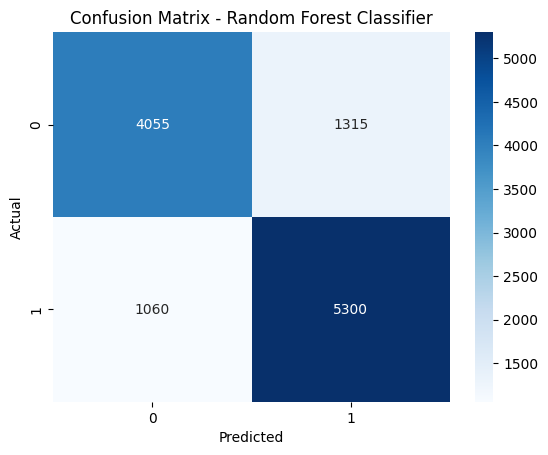

In [92]:
# Confusion Metrix for better visuals

cm = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

In [93]:
## Comparing Performance Metrics Across Models

# Create a dictionary that stores evaluation metrics for each algorithm
comparison_data = {
    'Metric': [
        'Accuracy (Train)', 'Accuracy (Test)',
        'Precision (Train)', 'Precision (Test)',
        'Recall (Train)', 'Recall (Test)',
        'F1-Score (Train)', 'F1-Score (Test)'
    ],
    'Decision_Tree': [
        acc_dt_train, acc_dt_test,
        pr_dt_train, pr_dt_test,
        rc_dt_train, rc_dt_test,
        f1_dt_train, f1_dt_test
    ],
    'Random_Forest': [
        acc_rf_train, acc_rf_test,
        pr_rf_train, pr_rf_test,
        rc_rf_train, rc_rf_test,
        f1_rf_train, f1_rf_test
    ],
    'Logistic_Regression': [
        acc_lr_train, acc_lr_test,
        pr_lr_train, pr_lr_test,
        rc_lr_train, rc_lr_test,
        f1_lr_train, f1_lr_test
    ]
}

# Convert the dictionary to a DataFrame for better visualization
model_metrics_df = pd.DataFrame(comparison_data)

# Display the comparison table
model_metrics_df

,Metric,Decision_Tree,Random_Forest,Logistic_Regression
0,Accuracy (Train),0.824632,0.824632,0.913850
1,Accuracy (Test),0.797528,0.797528,0.913299
2,Precision (Train),0.825509,0.825509,0.914519
3,Precision (Test),0.801209,0.801209,0.913097
4,Recall (Train),0.857884,0.857884,0.927830
5,Recall (Test),0.833333,0.833333,0.928459
6,F1-Score (Train),0.841385,0.841385,0.921127
7,F1-Score (Test),0.816956,0.816956,0.920714


### In Conclusion

- **Word Frequency Analysis:**  
  The word clouds for true and fake news showed that the most frequent words are quite similar in both classes, making it difficult to distinguish between them based solely on single-word frequency.

- **N-gram Insights:**  
  Unigram (single word) analysis did not reveal significant differences between true and fake news. However, bigram and trigram analyses provided more insight. Fake news articles often contained recurring phrases like "police officer", "getty image", and "screen capture", especially in trigrams involving media references. This suggests that fake news tends to use certain repeated patterns and phrases, particularly those referencing images and videos.

- **Model Performance:**  
  Among the three models tested (Logistic Regression, Decision Tree, Random Forest), **Logistic Regression** performed best, achieving the highest F1-score, precision, and recall on the validation set.  
  - **Accuracy (Test):** 0.913  
  - **Precision (Test):** 0.913  
  - **Recall (Test):** 0.929  
  - **F1-score (Test):** 0.921  

- **Metric Selection:**  
  While all metrics are important, F1-score was prioritized as it balances both precision and recall, which is crucial for fake news detection where both false positives and false negatives have significant consequences.

- **Semantic Classification Impact:**  
  Using Word2Vec embeddings and semantic features, rather than just surface-level word counts, improved the model's ability to capture context and meaning, leading to more robust classification.

**In summary:**  
Semantic classification using Word2Vec and supervised models, especially Logistic Regression, effectively distinguishes fake from true news when combined with n-gram analysis. The approach highlights the importance of context and phrase patterns in fake news detection, and demonstrates that a balanced metric like F1-score is key for evaluating model performance in this domain.